## Requirement

In [16]:
import tensorflow as tf
import keras
import sys

print("TF:", tf.__version__)
print("Keras:", keras.__version__)
print("Python:", sys.version)
print(tf.config.list_physical_devices('GPU'))

TF: 2.19.0
Keras: 3.13.2
Python: 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:16:45) [MSC v.1942 64 bit (AMD64)]
[]


## Loading Datasets

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
import kagglehub
import os
os.environ['KAGGLEHUB_CACHE'] = "D:/Training_Datasets"

# Download latest version
db1 = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")

print("Path to dataset files:", db1)

# Download latest version
db2 = kagglehub.dataset_download("doctorstrange420/real-and-fake-ai-generated-art-images-dataset")

print("Path to dataset files:", db2)

100%|██████████| 9.76G/9.76G [1:13:21<00:00, 2.38MB/s]

Extracting files...


Path to dataset files: D:/Training_Datasets\datasets\alessandrasala79\ai-vs-human-generated-dataset\versions\4


100%|██████████| 271M/271M [01:59<00:00, 2.37MB/s] 

Extracting files...


Path to dataset files: D:/Training_Datasets\datasets\doctorstrange420\real-and-fake-ai-generated-art-images-dataset\versions\1


In [7]:
import pandas as pd
import os
import numpy as np
from PIL import Image
from pathlib import Path
import random

def inter_til_img(image_folder):

  valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
  img_paths_found = []

  for item_name in os.listdir(image_folder):
    full_item_path = os.path.join(image_folder, item_name)

    if os.path.isfile(full_item_path) and item_name.lower().endswith(valid_extensions):
      img_paths_found.append(image_folder)
      return img_paths_found

    elif os.path.isdir(full_item_path):
      # Recursively call for subdirectories and extend the list
      img_paths_found.extend(inter_til_img(full_item_path))
  return img_paths_found

def load_dataset(image_folder, labels_path = None, img_size = (380,380), csv = False, csv_head = ['file_name', 'label'], custom_heading = {}, limit = None, shuffle = True, random_seed = 42):
    # 1. Create a mapping dictionary
    # We transform 'train_data/abc.jpg' -> 'abc.jpg' using os.path.basename
    label_map = {}
    img_paths = []

    labels = []

    if(labels_path is None):
      for dir in inter_til_img(image_folder):
        img_labels = os.path.basename(dir)
        for img_name in os.listdir(dir):
            img_paths.append(os.path.join(dir, img_name))
            label_map[img_name] = img_labels

    if(csv):
      df_labels = pd.read_csv(labels_path)

      for _, row in df_labels.iterrows():
          # Replace 'id' and 'label' with the actual column names in your CSV
          full_name_in_label = row[csv_head[0]]
          clean_name = os.path.basename(full_name_in_label)
          label_map[clean_name] = str(row[csv_head[1]])
          img_paths.append(os.path.join(image_folder, full_name_in_label))

    if(custom_heading):
      for key, value in label_map.items():
        if value in custom_heading.keys():
          label_map[key] = custom_heading[value]

    if(shuffle):
      random.Random(random_seed).shuffle(img_paths)


    if limit is not None:
      img_paths = img_paths[:limit]

    print(f"Mapping created for {len(label_map)} entries.")
    # Example lookup:
    example_key = list(label_map.keys())[0]
    print(f"Example: Filename '{example_key}' maps to label '{label_map[example_key]}'")

    for img in img_paths:
        # (Add your image loading logic here, e.g., PIL or cv2)
        filename = os.path.basename(img)
        labels.append(label_map[filename])

    print("Datasets Loaded!")
    return img_paths, labels

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os

# Using the function
images1, labels1 = load_dataset(db2, custom_heading = {"FAKE": 1, "REAL": 0}, limit = 3000)

images2, labels2 = load_dataset(db1, labels_path = os.path.join(db1, "train.csv"), csv = True, limit = 22000)

images = np.concatenate([images1, images2], axis=0)
# Combine the label arrays
labels = np.concatenate([labels1, labels2], axis=0)

print(f"Combined Images Shape: {images.shape}")
print(f"Combined Labels Shape: {labels.shape}")

# Split into train/test (0.2 = train 80% : test 20% split)
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

Mapping created for 21642 entries.
Example: Filename 'img000006.jpg' maps to label '1'
Datasets Loaded!
Mapping created for 79950 entries.
Example: Filename 'a6dcb93f596a43249135678dfcfc17ea.jpg' maps to label '1'
Datasets Loaded!
Combined Images Shape: (25000,)
Combined Labels Shape: (25000,)


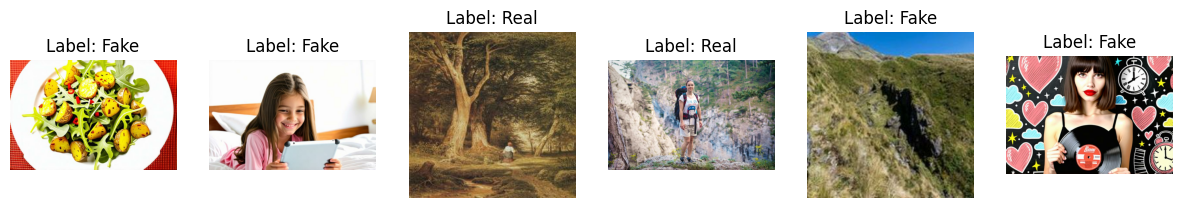

In [10]:
import matplotlib.pyplot as plt
import tensorflow as tf
# Let's look at the first 5 images in X_train
plt.figure(figsize=(15, 6))
for i in range(6):
    image = tf.io.read_file(X_train[i])
    image = tf.image.decode_jpeg(image, channels=3)
    plt.subplot(1, 6, i+1)
    plt.imshow(image)

    # The shortcut version:
    # We convert y_train[i] to int just in case it's a string '1' or '0'
    label_word = 'Real' if int(y_train[i]) == 0 else 'Fake'

    plt.title(f"Label: {label_word}")
    plt.axis('off')
plt.show()

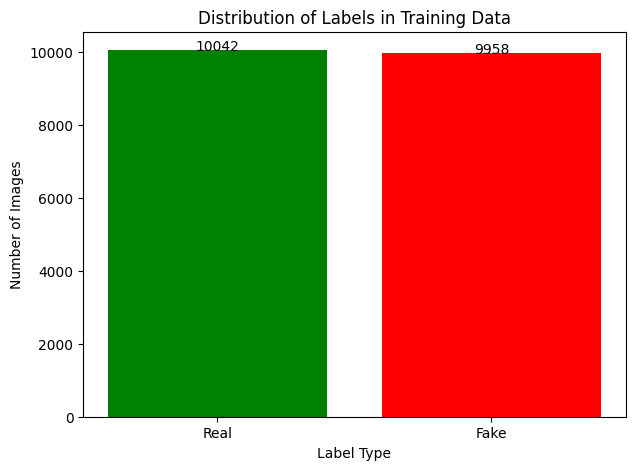

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Count the occurrences of each label
# unique: [0, 1], counts: [number of 0s, number of 1s]
unique, counts = np.unique(y_train, return_counts=True)

# 2. Map the numeric labels to names for the graph
label_names = ['Real' if int(u) == 0 else 'Fake' for u in unique]

# 3. Create the Bar Graph
plt.figure(figsize=(7, 5))
plt.bar(label_names, counts, color=['green', 'red'])

# 4. Add decorations
plt.title("Distribution of Labels in Training Data")
plt.xlabel("Label Type")
plt.ylabel("Number of Images")

# Optional: Add the exact count numbers on top of the bars
for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center')

plt.show()

## Pre-processing

### Efficient Data Loading with tf.data
Instead of loading all images into memory at once, we use a generator-style pipeline to load images on-the-fly.

#### Load Images for Model Training


In [ ]:
# import numpy as np
# from PIL import Image
# from pathlib import Path
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder

# def load_images_from_folder(dataset_path, image_size=(224, 224), target_mode=None):

#     """
#     Load images and labels from a folder structure where each subfolder is a class.
#     Automatically detects image modes and converts to a consistent format.

#     Args:
#         dataset_path: Path to the dataset folder (e.g., '../assets/dataset')
#         image_size: Tuple for resizing images (width, height) | Default: (224,224)
#         target_mode: Target color mode ('RGB', 'L', or None for auto-detection) | Default: None

#     Returns:
#         images: Numpy array of images
#         labels: Numpy array of encoded labels (it got number label from LabelEncoder. {Ex. labels = [1,2,3,2,1,3...]})
#         label_encoder: Fitted LabelEncoder for decoding predictions(it knows what 0 or 1 represent. {Ex. Cat = 0, Dog = 1})
#     """

#     images = []
#     labels = []
#     # The set() function create a list and make sure that every items are unique
#     detected_modes = set()
#     detected_format = set()
#     dataset_path = Path(dataset_path)

#     # Define the extensions you want to find
#     valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

#     # First pass: detect modes
#     for label_dir in dataset_path.iterdir():
#         if label_dir.is_dir():
#             for img_path in label_dir.glob('*'):
#                 if img.suffix.lower() in valid_extensions:
#                     detected_format.add(img_path.suffix.lower())
#                     try:
#                         with Image.open(img_path) as img:
#                             detected_modes.add(img.mode)
#                             # Load image using PIL
#                             img = Image.open(img_path)
#                             # Convert to target mode if needed
#                             if img.mode != target_mode:
#                                 img = img.convert(target_mode)
#                             # Resize
#                             img = img.resize(image_size)
#                             # Convert to numpy array
#                             img_array = np.array(img)
#                             images.append(img_array)
#                             labels.append(label)
#                     except Exception as e:
#                         print(f"Error detecting mode for {img_path}: {e}")


#     print(f"File Formats: {detected_format}")


#     # Convert to numpy arrays for better calculation speed and utilities
#     images = np.array(images)
#     labels = np.array(labels)

#     # Encode labels {LabelEncoder will look at all of the unique items in a List and assign it a number}
#     label_encoder = LabelEncoder()
#     labels_encoded = label_encoder.fit_transform(labels)

#     # Print what just processed
#     print(f"Loaded {len(images)} images with {len(label_encoder.classes_)} classes: {list(label_encoder.classes_)}")
#     print(f"Final image shape: {images.shape}")

#     return images, labels_encoded, label_encoder

# # Using the function
# images, labels, label_encoder = load_images_from_folder('../assets/dataset')

# # Split into train/test (0.2 = train 80% : test 20% split)
# X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)


In [ ]:
# import numpy as np
# from PIL import Image
# from pathlib import Path
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder

# def load_images_from_folder(dataset_path, image_size=(224, 224), target_mode=None):

#     """
#     Load images and labels from a folder structure where each subfolder is a class.
#     Automatically detects image modes and converts to a consistent format.

#     Args:
#         dataset_path: Path to the dataset folder (e.g., '../assets/dataset')
#         image_size: Tuple for resizing images (width, height) | Default: (224,224)
#         target_mode: Target color mode ('RGB', 'L', or None for auto-detection) | Default: None

#     Returns:
#         images: Numpy array of images
#         labels: Numpy array of encoded labels (it got number label from LabelEncoder. {Ex. labels = [1,2,3,2,1,3...]})
#         label_encoder: Fitted LabelEncoder for decoding predictions(it knows what 0 or 1 represent. {Ex. Cat = 0, Dog = 1})
#     """

#     images = []
#     labels = []
#     # The set() function create a list and make sure that every items are unique
#     detected_modes = set()
#     detected_format = set()
#     dataset_path = Path(dataset_path)

#     # Define the extensions you want to find
#     valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

#     # First pass: detect modes
#     for label_dir in dataset_path.iterdir():
#         if label_dir.is_dir():
#             for img_path in label_dir.glob('*'):
#                 if img.suffix.lower() in valid_extensions:
#                     detected_format.add(img_path.suffix.lower())
#                     try:
#                         with Image.open(img_path) as img:
#                             detected_modes.add(img.mode)
#                             # Load image using PIL
#                             img = Image.open(img_path)
#                             # Convert to target mode if needed
#                             if img.mode != target_mode:
#                                 img = img.convert(target_mode)
#                             # Resize
#                             img = img.resize(image_size)
#                             # Convert to numpy array
#                             img_array = np.array(img)
#                             images.append(img_array)
#                             labels.append(label)
#                     except Exception as e:
#                         print(f"Error detecting mode for {img_path}: {e}")


#     print(f"File Formats: {detected_format}")


#     # Convert to numpy arrays for better calculation speed and utilities
#     images = np.array(images)
#     labels = np.array(labels)

#     # Encode labels {LabelEncoder will look at all of the unique items in a List and assign it a number}
#     label_encoder = LabelEncoder()
#     labels_encoded = label_encoder.fit_transform(labels)

#     # Print what just processed
#     print(f"Loaded {len(images)} images with {len(label_encoder.classes_)} classes: {list(label_encoder.classes_)}")
#     print(f"Final image shape: {images.shape}")

#     return images, labels_encoded, label_encoder

# # Using the function
# images, labels, label_encoder = load_images_from_folder('../assets/dataset')

# # Split into train/test (0.2 = train 80% : test 20% split)
# X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)


## Load Models

## Training

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

class ViTTokenAndPosition(layers.Layer):
    def __init__(self, dim, seq_len, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.seq_len = seq_len
        self.cls_token = self.add_weight(shape=(1, 1, dim), initializer="zeros", trainable=True, name="cls_token")
        self.pos_emb = self.add_weight(shape=(1, seq_len + 1, dim), initializer="random_normal", trainable=True, name="pos_emb")

    def call(self, x):
        batch_size = tf.shape(x)[0]
        # Broadcast class token to batch size
        cls_t = tf.broadcast_to(self.cls_token, [batch_size, 1, self.dim])
        # Concatenate cls_token with the sequence
        x = tf.concat([cls_t, x], axis=1)
        # Add positional embedding
        return x + self.pos_emb

def create_efficient_vit_tf(input_shape=(380, 380, 3), num_classes=2, dim=128, depth=2, heads=8, mlp_dim=268, l1_reg=0.001, l2_reg=0.001):
    # 1. Feature Extraction (EfficientNet B4 Pretrained)
    base_model = tf.keras.applications.EfficientNetB4(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False
    # Unfreeze last 0 layers of EfficientNet B4
    unfreeze = 40
    if unfreeze > 0:
      for i, layer in enumerate(base_model.layers[(-1 * unfreeze):]):
        layer.trainable = True
        # We add the length minus 10 to get the actual index
        print(f"Layer {len(base_model.layers)-10+i}: {layer.name} | Trainable: {layer.trainable}")


    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs) # For B4 @ 380x380, this results in (batch, 12, 12, 1792)

    # 2. Reshape to Sequence
    channels = x.shape[-1]
    seq_len = (x.shape[1] * x.shape[2])
    x = layers.Reshape((seq_len, channels))(x)

    # 3. Patch Embedding
    x = layers.Dense(dim)(x)

    # 4. Class Token & Positional Encoding
    x = ViTTokenAndPosition(dim, seq_len)(x)

    # 5. Transformer Blocks
    for _ in range(depth):
        # Attention
        attn_output = layers.MultiHeadAttention(num_heads=heads, key_dim=dim // heads)(x, x)
        x = layers.LayerNormalization(epsilon=1e-6)(x + layers.Dropout(0.5)(attn_output))

        # MLP
        ffn = models.Sequential([
            layers.Dense(mlp_dim, activation='gelu', kernel_regularizer=regularizers.l1_l2(l1=l1_reg, l2=l2_reg)),
            layers.Dense(dim, kernel_regularizer=regularizers.l1_l2(l1=l1_reg, l2=l2_reg)),
            layers.Dropout(0.5)
        ])
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn(x))

    # 6. Classification Head
    cls_token_final = layers.Lambda(lambda t: t[:, 0])(x)
    outputs = layers.Dense(num_classes, activation='softmax', kernel_regularizer=regularizers.l1_l2(l1=l1_reg, l2=l2_reg))(cls_token_final)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Instantiate with B4 backbone
# You can adjust l1_reg and l2_reg values as needed, e.g., l1_reg=0.0001, l2_reg=0.0001
model_tf = create_efficient_vit_tf(input_shape=(380, 380, 3), l1_reg=0.0001, l2_reg=0.0001)
model_tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_tf.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step
Layer 465: block6h_se_squeeze | Trainable: True
Layer 466: block6h_se_reshape | Trainable: True
Layer 467: block6h_se_reduce | Trainable: True
Layer 468: block6h_se_expand | Trainable: True
Layer 469: block6h_se_excite | Trainable: True
Layer 470: block6h_project_conv | Trainable: True
Layer 471: block6h_project_bn | Trainable: True
Layer 472: block6h_drop | Trainable: True
Layer 473: block6h_add | Trainable: True
Layer 474: block7a_expand_conv | Trainable: True
Layer 475: block7a_expand_bn | Trainable: True
Layer 476: block7a_expand_activation | Trainable: True
Layer 477: block7a_dwconv | Trainable: True
Layer 478: block7a_bn | Trainable: True
Layer 479: block7a_activation | Trainable: True
Layer 480: block7a_se_squeeze | Trainable: True
Layer 481: block7a_se_reshape | Trainable: True
Layer 482: block7a_se_reduce | Trainable: True
Layer 483: block7a_se_expand | Trainable: True
Layer 484: block7a_se_excite | Trainable: True
Layer 485:

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb4      │ (None, 12, 12,    │ 17,673,823 │ input_layer_1[0]… │
│ (Functional)        │ 1792)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 144, 1792) │          0 │ efficientnetb4[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 144, 128)  │    229,504 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vi_t_token_and_pos… │ (None, 145, 128)  │     18,688 │ dense[0][0]       │
│ (ViTTokenAndPositi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 145, 128)  │     66,048 │ vi_t_token_and_p… │
│ (MultiHeadAttentio… │                   │            │ vi_t_token_and_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 145, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 145, 128)  │          0 │ vi_t_token_and_p… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 145, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 145, 128)  │     69,004 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 145, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 145, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 145, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 145, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 145, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 145, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 145, 128)  │     69,004 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 145, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][

 Total params: 18,193,401 (69.40 MB)

 Trainable params: 6,464,082 (24.66 MB)

 Non-trainable params: 11,729,319 (44.74 MB)

### Training the TensorFlow EfficientViT Model

We will now prepare the data for the TensorFlow model and start the training process. Note that we convert labels to integers because we used `sparse_categorical_crossentropy`.

In [15]:
import tensorflow as tf

# Check if a GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"GPU found: {gpu_devices[0]}")
    print("TensorFlow will use the GPU for training.")
else:
    print("No GPU found. Training will proceed on the CPU (which will be much slower).")
    print("Go to Runtime -> Change runtime type and select a GPU hardware accelerator if needed.")

No GPU found. Training will proceed on the CPU (which will be much slower).
Go to Runtime -> Change runtime type and select a GPU hardware accelerator if needed.


In [ ]:
import tensorflow as tf

def load_and_preprocess_image(path, label, img_size=(380, 380), augment = True):
    # 1. Read the file from disk
    image = tf.io.read_file(path)
    # 2. Decode the compressed bytes into a pixel tensor
    image = tf.image.decode_jpeg(image, channels=3)
    # 3. Resize to the resolution the model expects
    image = tf.image.resize(image, img_size)
    # Normalize pixels to [0, 1] range BEFORE augmentation or clipping
    image = image / 255.0

    # 4. Apply Augmentations on [0, 1] range
    if augment:
      image = tf.image.random_flip_left_right(image)
      image = tf.image.random_flip_up_down(image)
      image = tf.image.random_brightness(image, max_delta=0.1)
      image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
      image = tf.image.random_saturation(image, lower=0.9, upper=1.1)
      image = tf.image.random_hue(image, max_delta=0.1)

      image = tf.clip_by_value(image, 0, 1)

    return image, label

# 1. Prepare the data
y_train_tf = y_train.astype(int)
y_test_tf = y_test.astype(int)

def prepare_ds(X, y, batch_size=24, training=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        # Buffer size matches training set size for perfect shuffling
        ds = ds.shuffle(buffer_size=len(X))
        ds = ds.map(lambda x, y: load_and_preprocess_image(x, y, augment=True), num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
        return ds

    ds = ds.map(lambda x, y: load_and_preprocess_image(x, y, augment=False), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 24
train_ds = prepare_ds(X_train, y_train_tf, batch_size=BATCH_SIZE, training=True)
test_ds = prepare_ds(X_test, y_test_tf, batch_size=BATCH_SIZE, training=False)

# 2. Define Callbacks
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 3. Start Training
EPOCHS = 20
history = model_tf.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stopping_cb],
    verbose=1
)

# 4. Evaluate
loss, accuracy = model_tf.evaluate(test_ds)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Epoch 1/20


In [ ]:
import matplotlib.pyplot as plt

# Take one batch from the training dataset
for images_batch, labels_batch in train_ds.take(1):
    print(f"Batch Image Shape: {images_batch.shape}")
    print(f"Image Pixel Range: Min={images_batch.numpy().min()}, Max={images_batch.numpy().max()}")

    # Display the first image in the batch to verify preprocessing
    plt.imshow(images_batch[0])
    plt.title(f"Label: {labels_batch[0].numpy()}")
    plt.axis('off')
    plt.show()

### Model Performance Visualization
We will plot the accuracy and loss curves to check for overfitting and then generate a confusion matrix to evaluate classification errors.

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Get predictions using the test dataset pipeline
print("Generating predictions...")
y_true = []
y_pred_probs = []

# Iterate through the test dataset to get true labels and predictions
for images, labels in test_ds:
    preds = model_tf.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(y_true)

# 2. Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

In [ ]:
import os

# Define the path in your Google Drive
drive_save_path = '"D:\Trained_Models"'

# Create the directory if it doesn't exist
if not os.path.exists(drive_save_path):
    os.makedirs(drive_save_path)

# Save the model
model_save_full_path = os.path.join(drive_save_path, 'efficient_vit_model.keras')
model_tf.save(model_save_full_path)

print(f"Model successfully saved to: {model_save_full_path}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def visualize_attention(model, dataset, sample_index=0):
    # 1. Grab a sample
    for imgs, lbls in dataset.take(1):
        img = imgs[sample_index]
        label = lbls[sample_index]

    # 2. Identify the backbone and the target layer within it
    backbone = next(l for l in model.layers if 'efficientnet' in l.name.lower())
    target_layer = backbone.get_layer('top_activation')

    # 3. Create a model that outputs the target layer and the backbone's final output
    # We'll use this to bridge the gap
    backbone_model = tf.keras.Model(backbone.input, [target_layer.output, backbone.output])

    img_tensor = tf.expand_dims(img, 0)

    with tf.GradientTape() as tape:
        # Step A: Get backbone activations
        conv_outputs, backbone_final = backbone_model(img_tensor)
        # Step B: Crucial - watch the conv_outputs for gradient tracking
        tape.watch(conv_outputs)

        # Step C: Complete the forward pass manually through the model's head
        # We find the transformer layers and call them sequentially
        x = backbone_final
        found = False
        for layer in model.layers:
            if found:
                # MultiHeadAttention and other transformer layers expect different inputs
                # but the model's __call__ or layer call handles it if we pass properly
                try:
                    x = layer(x)
                except TypeError:
                    # For layers like MultiHeadAttention that might need (query, value)
                    x = layer(x, x)
            if layer == backbone:
                found = True

        predictions = x
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    # 4. Calculate gradients of the loss w.r.t. the conv output
    grads = tape.gradient(loss, conv_outputs)
    if grads is None:
        print("Error: Gradients are None. This usually happens if the layer is not part of the backprop path.")
        return

    # 5. Generate Heatmap
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(tf.multiply(weights, conv_outputs), axis=-1).numpy()[0]

    cam = np.maximum(cam, 0)
    if cam.max() != 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min())

    cam = tf.image.resize(cam[..., np.newaxis], (380, 380)).numpy().reshape((380, 380))

    # 6. Plot results
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original (Label: {'Fake' if label==1 else 'Real'})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(cam, cmap='jet', alpha=0.4)
    plt.title("Model Focus (Grad-CAM)")
    plt.axis('off')
    plt.show()

visualize_attention(model_tf, test_ds)